In [1]:
import warnings

import astropy.units
import FunctionLib as FL
import inspect
from tqdm import tqdm
import astropy
import wave
from matplotlib.image import resample
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import defaultdict
import re
import scipy

mpl.rcParams['font.family'] = 'serif'


warnings.filterwarnings("ignore")

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(os.path.expanduser(
    '~/DustCurve/DJAv4Catalog.pkl'))
print(DJAv4Catalog.sample_num())

DJAv4Catalog.to_dataframe()

459


,survey_id_subid,survey_id,prism_filepath,prism_redshift,grating_filepaths,grating_redshifts,determined_redshift,file_count,available_filters,properties
0,snh0pe-v4_4446_102,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,0.2259,{'g235m-f170lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g235m-f170lp': nan, 'g140m-f100lp': nan}",0.2259,3,"{g235m-f170lp, prism-clear, g140m-f100lp}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
1,snh0pe-v4_4446_143,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,1.6318,{'g235m-f170lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g235m-f170lp': 1.6309, 'g140m-f100lp': 1.6313}",1.6311,3,"{g235m-f170lp, prism-clear, g140m-f100lp}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
2,snh0pe-v4_4446_285,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,0.4446,{'g235m-f170lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g235m-f170lp': 0.4462, 'g140m-f100lp': 0.4462}",0.4462,3,"{g235m-f170lp, prism-clear, g140m-f100lp}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
3,snh0pe-v4_4446_29,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,1.7834,{'g235m-f170lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g235m-f170lp': 1.7796, 'g140m-f100lp': 1.7799}",1.77975,3,"{g235m-f170lp, prism-clear, g140m-f100lp}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
4,snh0pe-v4_4446_123,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,1.7855,{'g235m-f170lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g235m-f170lp': 1.7851, 'g140m-f100lp': 1.7855}",1.7855,3,"{g235m-f170lp, prism-clear, g140m-f100lp}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
...,...,...,...,...,...,...,...,...,...,...
32564,ceers-ddt-v4_2750_1636,ceers-ddt-v4,/home/xingyaocai/DJAv4/ceers-ddt-v4/ceers-ddt-...,3.0592,{},{},3.0592,1,{prism-clear},"{'redshift_conflict': False, 'Sample_Flag': Fa..."
32565,ceers-ddt-v4_2750_3213,ceers-ddt-v4,/home/xingyaocai/DJAv4/ceers-ddt-v4/ceers-ddt-...,4.8013,{},{},4.8013,1,{prism-clear},"{'redshift_conflict': False, 'Sample_Flag': Fa..."
32566,ceers-ddt-v4_2750_340,ceers-ddt-v4,/home/xingyaocai/DJAv4/ceers-ddt-v4/ceers-ddt-...,0.9585,{},{},0.9585,1,{prism-clear},"{'redshift_conflict': False, 'Sample_Flag': Fa..."
32567,ceers-ddt-v4_2750_21413,ceers-ddt-v4,/home/xingyaocai/DJAv4/ceers-ddt-v4/ceers-ddt-...,2.1402,{},{},2.1402,1,{prism-clear},"{'redshift_conflict': False, 'Sample_Flag': Fa..."


In [ ]:
import numpy as np
import astropy.units as u
import astropy.nddata
from scipy import stats
import matplotlib.pyplot as plt

def estimate_snr_error(spectrum, line_center_wavelength, continuum_width=150*u.AA,
                      sigma_range=3, n_random_samples=1000, plot_diagnostics=False):
    """
    估算发射线的信噪比误差，通过在发射线两侧连续谱区域随机采样计算不确定性。

    Parameters
    ----------
    spectrum : Spectrum_1d
        包含光谱数据的Spectrum_1d实例
    line_center_wavelength : astropy.units.Quantity
        发射线的中心波长（静止系）
    continuum_width : astropy.units.Quantity, optional
        连续谱采样区域的总宽度，默认150埃（发射线两侧各75埃）
    sigma_range : float, optional
        测量区域的范围，以sigma为单位，默认为3倍sigma
    n_random_samples : int, optional
        随机采样的次数，默认1000次
    plot_diagnostics : bool, optional
        是否绘制诊断图，默认False

    Returns
    -------
    dict
        包含误差估算结果的字典，包括：
        - 'continuum_std': 连续谱标准差
        - 'integration_uncertainty': 积分不确定性
        - 'snr_estimate': 信噪比估计
        - 'random_integrals': 随机采样得到的积分值数组
        - 'continuum_regions': 使用的连续谱区域信息
    """

    # 转换到统一单位
    line_center = line_center_wavelength.to(u.AA)
    continuum_width = continuum_width.to(u.AA)

    # 获取光谱数据
    if hasattr(spectrum, 'processing_wavelengths') and spectrum.processing_wavelengths is not None:
        wavelengths = spectrum.processing_wavelengths.convert_unit_to(u.AA).data
        flux = spectrum.processing_flux.data
        flux_unit = spectrum.processing_flux.unit
    elif hasattr(spectrum, 'restframe_wavelengths') and spectrum.restframe_wavelengths is not None:
        wavelengths = spectrum.restframe_wavelengths.convert_unit_to(u.AA).data
        flux = spectrum.observed_flux_lambda.data if spectrum.observed_flux_lambda is not None else spectrum.observed_flux_nu.data
        flux_unit = spectrum.observed_flux_lambda.unit if spectrum.observed_flux_lambda is not None else spectrum.observed_flux_nu.unit
    else:
        raise ValueError("Spectrum对象缺少必要的波长和流量数据")

    # 确保数据是numpy数组
    if isinstance(wavelengths, u.Quantity):
        wavelengths = wavelengths.value
    if isinstance(flux, u.Quantity):
        flux = flux.value

    # 定义连续谱区域（发射线两侧）
    half_width = continuum_width.value / 2
    left_region_start = line_center.value - continuum_width.value
    left_region_end = line_center.value - half_width
    right_region_start = line_center.value + half_width
    right_region_end = line_center.value + continuum_width.value

    # 选择连续谱区域的数据点
    left_mask = (wavelengths >= left_region_start) & (wavelengths <= left_region_end)
    right_mask = (wavelengths >= right_region_start) & (wavelengths <= right_region_end)
    continuum_mask = left_mask | right_mask

    if np.sum(continuum_mask) < 10:
        raise ValueError("连续谱区域数据点太少，无法进行可靠的误差估算")

    continuum_wavelengths = wavelengths[continuum_mask]
    continuum_flux = flux[continuum_mask]

    # 计算连续谱的基本统计量
    continuum_mean = np.mean(continuum_flux)
    continuum_std = np.std(continuum_flux, ddof=1)

    # 估算发射线测量区域的宽度
    # 这里我们假设一个典型的发射线宽度作为初始估计
    # 在实际应用中，您可能需要根据具体的发射线特性调整
    estimated_line_width = 5.0  # 埃，可以根据需要调整
    measurement_width = sigma_range * estimated_line_width

    # 计算测量区域内的像素数（用于积分）
    wavelength_step = np.median(np.diff(wavelengths))
    n_pixels_in_measurement = int(measurement_width / wavelength_step)

    # 随机采样计算积分不确定性
    random_integrals = []
    np.random.seed(42)  # 为了结果的可重复性

    for i in range(n_random_samples):
        # 在连续谱区域随机选择起点
        if len(continuum_wavelengths) < n_pixels_in_measurement:
            # 如果连续谱区域太小，使用全部数据
            sample_flux = continuum_flux
        else:
            # 随机选择起点
            start_idx = np.random.randint(0, len(continuum_flux) - n_pixels_in_measurement + 1)
            end_idx = start_idx + n_pixels_in_measurement
            sample_flux = continuum_flux[start_idx:end_idx]

        # 去除信号后的连续谱积分（这里假设连续谱是平的）
        # 减去平均连续谱水平，然后计算积分
        detrended_flux = sample_flux - continuum_mean
        integral_value = np.trapz(detrended_flux, dx=wavelength_step)
        random_integrals.append(integral_value)

    random_integrals = np.array(random_integrals)
    integration_uncertainty = np.std(random_integrals, ddof=1)

    # 计算信噪比估计
    # 假设发射线在测量区域内的积分流量
    measurement_region_mask = (wavelengths >= line_center.value - measurement_width/2) & \
                             (wavelengths <= line_center.value + measurement_width/2)

    if np.sum(measurement_region_mask) > 0:
        line_region_flux = flux[measurement_region_mask]
        line_region_wavelengths = wavelengths[measurement_region_mask]

        # 估算发射线的积分流量（减去连续谱背景）
        line_integral = np.trapz(line_region_flux - continuum_mean,
                                line_region_wavelengths) if len(line_region_wavelengths) > 1 else 0

        # 计算信噪比
        snr_estimate = abs(line_integral) / integration_uncertainty if integration_uncertainty > 0 else 0
    else:
        line_integral = 0
        snr_estimate = 0

    # 诊断图
    if plot_diagnostics:
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

        # 1. 光谱概览和区域定义
        ax1.plot(wavelengths, flux, 'b-', alpha=0.7, label='完整光谱')
        ax1.axvspan(left_region_start, left_region_end, alpha=0.3, color='green', label='左连续谱区域')
        ax1.axvspan(right_region_start, right_region_end, alpha=0.3, color='green', label='右连续谱区域')
        ax1.axvspan(line_center.value - measurement_width/2, line_center.value + measurement_width/2,
                   alpha=0.3, color='red', label='发射线测量区域')
        ax1.axvline(line_center.value, color='red', linestyle='--', label='发射线中心')
        ax1.set_xlabel('波长 (Å)')
        ax1.set_ylabel(f'流量 ({flux_unit})')
        ax1.set_title('光谱区域定义')
        ax1.legend()
        ax1.grid(True)

        # 2. 连续谱区域详细视图
        ax2.plot(continuum_wavelengths, continuum_flux, 'go', alpha=0.7, label='连续谱数据点')
        ax2.axhline(continuum_mean, color='red', linestyle='-', label=f'平均值: {continuum_mean:.2e}')
        ax2.axhline(continuum_mean + continuum_std, color='orange', linestyle='--', label=f'+1σ: {continuum_std:.2e}')
        ax2.axhline(continuum_mean - continuum_std, color='orange', linestyle='--', label=f'-1σ')
        ax2.set_xlabel('波长 (Å)')
        ax2.set_ylabel(f'流量 ({flux_unit})')
        ax2.set_title('连续谱区域统计')
        ax2.legend()
        ax2.grid(True)

        # 3. 随机积分值分布
        ax3.hist(random_integrals, bins=50, alpha=0.7, density=True, color='skyblue', label='随机积分值')
        ax3.axvline(np.mean(random_integrals), color='red', linestyle='-', label=f'均值: {np.mean(random_integrals):.2e}')
        ax3.axvline(integration_uncertainty, color='orange', linestyle='--', label=f'标准差: {integration_uncertainty:.2e}')
        ax3.axvline(-integration_uncertainty, color='orange', linestyle='--')
        ax3.set_xlabel(f'积分值 ({flux_unit}·Å)')
        ax3.set_ylabel('概率密度')
        ax3.set_title('随机采样积分值分布')
        ax3.legend()
        ax3.grid(True)

        # 4. 误差估算总结
        ax4.text(0.1, 0.8, f'连续谱标准差: {continuum_std:.3e} {flux_unit}', transform=ax4.transAxes, fontsize=12)
        ax4.text(0.1, 0.7, f'积分不确定性: {integration_uncertainty:.3e} {flux_unit}·Å', transform=ax4.transAxes, fontsize=12)
        ax4.text(0.1, 0.6, f'估算信噪比: {snr_estimate:.2f}', transform=ax4.transAxes, fontsize=12)
        ax4.text(0.1, 0.5, f'采样次数: {n_random_samples}', transform=ax4.transAxes, fontsize=12)
        ax4.text(0.1, 0.4, f'测量区域宽度: {measurement_width:.1f} Å', transform=ax4.transAxes, fontsize=12)
        ax4.text(0.1, 0.3, f'连续谱区域宽度: {continuum_width.value:.1f} Å', transform=ax4.transAxes, fontsize=12)
        ax4.text(0.1, 0.2, f'连续谱数据点数: {len(continuum_flux)}', transform=ax4.transAxes, fontsize=12)
        ax4.set_xlim(0, 1)
        ax4.set_ylim(0, 1)
        ax4.set_title('误差估算总结')
        ax4.axis('off')

        plt.tight_layout()
        plt.show()

    # 返回结果
    result = {
        'continuum_std': continuum_std * flux_unit,
        'integration_uncertainty': integration_uncertainty * flux_unit * u.AA,
        'snr_estimate': snr_estimate,
        'random_integrals': random_integrals * flux_unit * u.AA,
        'continuum_regions': {
            'left_region': (left_region_start, left_region_end),
            'right_region': (right_region_start, right_region_end),
            'n_continuum_pixels': len(continuum_flux),
            'continuum_mean': continuum_mean * flux_unit,
            'continuum_std': continuum_std * flux_unit
        },
        'measurement_info': {
            'line_center': line_center,
            'measurement_width': measurement_width * u.AA,
            'n_pixels_in_measurement': n_pixels_in_measurement,
            'estimated_line_integral': line_integral * flux_unit * u.AA if 'line_integral' in locals() else None
        }
    }

    return result


def monte_carlo_error_estimation(spectrum, line_center_wavelength, fit_function,
                                n_iterations=1000, noise_model='gaussian',
                                plot_diagnostics=False):
    """
    使用蒙特卡罗方法估算发射线拟合参数的误差。

    Parameters
    ----------
    spectrum : Spectrum_1d
        包含光谱数据的Spectrum_1d实例
    line_center_wavelength : astropy.units.Quantity
        发射线的中心波长（静止系）
    fit_function : callable
        拟合函数，应该接受spectrum参数并返回拟合结果
    n_iterations : int, optional
        蒙特卡罗迭代次数，默认1000
    noise_model : str, optional
        噪声模型类型，'gaussian'或'poisson'，默认'gaussian'
    plot_diagnostics : bool, optional
        是否绘制诊断图，默认False

    Returns
    -------
    dict
        包含蒙特卡罗误差估算结果的字典
    """

    # 获取原始光谱数据
    if hasattr(spectrum, 'processing_wavelengths') and spectrum.processing_wavelengths is not None:
        wavelengths = spectrum.processing_wavelengths.convert_unit_to(u.AA).data
        original_flux = spectrum.processing_flux.data
        flux_unit = spectrum.processing_flux.unit
    else:
        wavelengths = spectrum.restframe_wavelengths.convert_unit_to(u.AA).data
        original_flux = spectrum.observed_flux_lambda.data if spectrum.observed_flux_lambda is not None else spectrum.observed_flux_nu.data
        flux_unit = spectrum.observed_flux_lambda.unit if spectrum.observed_flux_lambda is not None else spectrum.observed_flux_nu.unit

    # 确保数据是numpy数组
    if isinstance(wavelengths, u.Quantity):
        wavelengths = wavelengths.value
    if isinstance(original_flux, u.Quantity):
        original_flux = original_flux.value

    # 估算噪声水平（使用信噪比方法的结果）
    snr_result = estimate_snr_error(spectrum, line_center_wavelength, plot_diagnostics=False)
    noise_level = snr_result['continuum_std'].value

    # 存储拟合结果
    fit_results = []
    successful_fits = 0

    np.random.seed(42)  # 确保可重复性

    for i in range(n_iterations):
        # 生成噪声扰动
        if noise_model == 'gaussian':
            noise = np.random.normal(0, noise_level, size=len(original_flux))
        elif noise_model == 'poisson':
            # 对于泊松噪声，假设原始流量代表期望计数
            # 这里做简化处理，实际应用中可能需要更复杂的模型
            noise = np.random.poisson(np.maximum(original_flux, 1)) - original_flux
        else:
            raise ValueError("noise_model必须是'gaussian'或'poisson'")

        # 创建扰动后的光谱
        perturbed_flux = original_flux + noise

        # 创建临时的Spectrum_1d对象
        temp_spectrum = Spectrum_1d(
            observed_wavelengths=wavelengths * u.AA,
            observed_flux_lambda=perturbed_flux * flux_unit,
            redshift=spectrum.redshift
        )

        # 设置处理区域（如果原始光谱有设置的话）
        if hasattr(spectrum, 'processing_wavelengths'):
            temp_spectrum.processing_wavelengths = astropy.nddata.NDDataArray(
                data=wavelengths, unit=u.AA)
            temp_spectrum.processing_flux = astropy.nddata.NDDataArray(
                data=perturbed_flux, unit=flux_unit)

        try:
            # 执行拟合
            fit_result = fit_function(temp_spectrum)

            if fit_result.get('success', False):
                fit_results.append(fit_result)
                successful_fits += 1

        except Exception as e:
            # 拟合失败时跳过
            continue

    if successful_fits == 0:
        raise RuntimeError("所有蒙特卡罗迭代都拟合失败")

    # 分析拟合参数的分布
    parameter_distributions = {}

    if successful_fits > 0:
        # 提取所有成功拟合的参数
        for param_name in fit_results[0]['parameters'].keys():
            param_values = []
            for result in fit_results:
                if 'parameters' in result and param_name in result['parameters']:
                    value = result['parameters'][param_name]
                    if isinstance(value, u.Quantity):
                        param_values.append(value.value)
                    else:
                        param_values.append(value)

            if param_values:
                param_values = np.array(param_values)
                parameter_distributions[param_name] = {
                    'mean': np.mean(param_values),
                    'std': np.std(param_values, ddof=1),
                    'median': np.median(param_values),
                    'percentile_16': np.percentile(param_values, 16),
                    'percentile_84': np.percentile(param_values, 84),
                    'values': param_values
                }

    # 诊断图
    if plot_diagnostics and parameter_distributions:
        n_params = len(parameter_distributions)
        fig, axes = plt.subplots(2, max(2, (n_params + 1) // 2), figsize=(15, 10))
        axes = axes.flatten()

        for i, (param_name, param_dist) in enumerate(parameter_distributions.items()):
            if i < len(axes):
                ax = axes[i]
                values = param_dist['values']

                # 绘制直方图
                ax.hist(values, bins=30, alpha=0.7, density=True, color='skyblue')
                ax.axvline(param_dist['mean'], color='red', linestyle='-',
                          label=f"均值: {param_dist['mean']:.3e}")
                ax.axvline(param_dist['percentile_16'], color='orange', linestyle='--',
                          label=f"16%: {param_dist['percentile_16']:.3e}")
                ax.axvline(param_dist['percentile_84'], color='orange', linestyle='--',
                          label=f"84%: {param_dist['percentile_84']:.3e}")

                ax.set_xlabel(f'{param_name}')
                ax.set_ylabel('概率密度')
                ax.set_title(f'{param_name} 分布')
                ax.legend(fontsize=8)
                ax.grid(True)

        # 隐藏多余的子图
        for i in range(len(parameter_distributions), len(axes)):
            axes[i].set_visible(False)

        plt.tight_layout()
        plt.show()

    return {
        'successful_fits': successful_fits,
        'total_iterations': n_iterations,
        'success_rate': successful_fits / n_iterations,
        'parameter_distributions': parameter_distributions,
        'noise_level_used': noise_level * flux_unit,
        'snr_baseline': snr_result,
        'fit_results': fit_results
    }


# 使用示例函数
def example_usage_snr_error():
    """
    展示如何使用SNR误差估算函数的示例
    """
    # 这是一个使用示例，展示函数的调用方式

    # 假设您已经有一个Spectrum_1d对象
    # spectrum = Load_Spectrum_From_Fits('your_spectrum_file.fits')

    # 设置发射线中心波长（例如Hα线）
    # ha_line = 6562.8 * u.AA

    # 调用SNR误差估算
    # snr_error_result = estimate_snr_error(
    #     spectrum=spectrum,
    #     line_center_wavelength=ha_line,
    #     continuum_width=150*u.AA,  # 连续谱区域总宽度
    #     sigma_range=3,             # 测量区域范围
    #     n_random_samples=1000,     # 随机采样次数
    #     plot_diagnostics=True      # 显示诊断图
    # )

    # 调用蒙特卡罗误差估算
    # def simple_gaussian_fit(spec):
    #     fitter = SpectralLineFitter(spec, ha_line)
    #     return fitter.fit_single_gaussian()

    # mc_error_result = monte_carlo_error_estimation(
    #     spectrum=spectrum,
    #     line_center_wavelength=ha_line,
    #     fit_function=simple_gaussian_fit,
    #     n_iterations=1000,
    #     plot_diagnostics=True
    # )

    print("示例函数调用代码已准备就绪。")
    print("请根据您的实际光谱数据调整参数。")

    return True

if __name__ == "__main__":
    example_usage_snr_error()

In [ ]:
import warnings

import astropy.units
import FunctionLib as FL
import inspect
from tqdm import tqdm
import astropy
import wave
from matplotlib.image import resample
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import defaultdict
import re
import scipy

mpl.rcParams['font.family'] = 'serif'


warnings.filterwarnings("ignore")

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(os.path.expanduser(
    '~/DustCurve/DJAv4Catalog.pkl'))
print(DJAv4Catalog.sample_num())

def balmer_bin(balmer_decrement):
    """
    Bin the Balmer decrement into categories.
    """
    if balmer_decrement<0:
        return 0
    elif balmer_decrement<0.2:
        return 1
    elif balmer_decrement<0.5:
        return 2
    elif balmer_decrement<0.7:
        return 3
    elif balmer_decrement<1:
        return 4


balmer_bin0=[]
balmer_bin1=[]
balmer_bin2=[]
balmer_bin3=[]
balmer_bin4=[]
balmer_number=[]


for id,catalog in DJAv4Catalog.catalog_iterator():
    if not catalog['properties']['Sample_Flag']:
        continue
    if 'Halpha_Fit_Result' in catalog['properties'] and 'Hbeta_Fit_Result' in catalog['properties']:
        Halpha_Fit_Result = catalog['properties']['Halpha_Fit_Result']
        Hbeta_Fit_Result = catalog['properties']['Hbeta_Fit_Result']

        halpha_intensity = Halpha_Fit_Result['integrated_flux']
        hbeta_intensity = Hbeta_Fit_Result['integrated_flux']
        balmer=np.log(halpha_intensity/hbeta_intensity/2.88)
        balmer_number.append(balmer)

    prism_filepath = os.path.expanduser('~/' + catalog['prism_filepath'][16:])

    spectrum=FL.Load_Spectrum_From_Fits(prism_filepath,catalog['determined_redshift'])



    bin_index = balmer_bin(balmer)
    if bin_index == 0:
        balmer_bin0.append(spectrum)
    elif bin_index == 1:
        balmer_bin1.append(spectrum)
    elif bin_index == 2:
        balmer_bin2.append(spectrum)
    elif bin_index == 3:
        balmer_bin3.append(spectrum)
    elif bin_index == 4:
        balmer_bin4.append(spectrum)



print(f'Balmer bin 0: {len(balmer_bin0)}')
print(f'Balmer bin 1: {len(balmer_bin1)}')
print(f'Balmer bin 2: {len(balmer_bin2)}')
print(f'Balmer bin 3: {len(balmer_bin3)}')
print(f'Balmer bin 4: {len(balmer_bin4)}')
print(f'Total: {len(balmer_bin0)+len(balmer_bin1)+len(balmer_bin2)+len(balmer_bin3)+len(balmer_bin4)}')


import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
#1684
class SpectrumAverager:
    def __init__(self):
        """
        初始化光谱平均器
        """
        self.spectra_data = []
        self.common_wavelength = None
        self.interpolated_fluxes = []
        self.normalized_fluxes = []  # 新增：存储归一化后的通量
        self.average_flux = None
        self.std_flux = None
        self.normalization_factors = []  # 新增：存储归一化因子

    def load_spectrum_list(self, spectrum_list):
        """
        从spectrum对象列表加载所有光谱

        参数:
        spectrum_list: spectrum对象列表
        """
        self.spectra_data = []
        successful_loads = 0

        for i, spectrum in enumerate(spectrum_list):
            try:
                # 验证spectrum对象是否有必要的属性
                if not hasattr(spectrum, 'processing_wavelengths') or \
                   not hasattr(spectrum, 'processing_flux'):
                    print(f"警告: spectrum {i} - 缺少processing_wavelengths或processing_flux属性")
                    continue

                # 获取数据
                wl = np.array(spectrum.processing_wavelengths)
                flux = np.array(spectrum.processing_flux)

                # 检查数据有效性
                if len(wl) == 0 or len(flux) == 0:
                    print(f"警告: spectrum {i} - 波长或通量数据为空")
                    continue

                if len(wl) != len(flux):
                    print(f"警告: spectrum {i} - 波长和通量数据长度不匹配 ({len(wl)} vs {len(flux)})")
                    continue

                # 去除NaN值
                mask = ~(np.isnan(wl) | np.isnan(flux))
                if np.sum(mask) < 2:
                    print(f"警告: spectrum {i} - 有效数据点太少")
                    continue

                wl_clean = wl[mask]
                flux_clean = flux[mask]

                # 按波长排序
                sort_idx = np.argsort(wl_clean)
                wl_sorted = wl_clean[sort_idx]
                flux_sorted = flux_clean[sort_idx]

                self.spectra_data.append({
                    'index': i,
                    'spectrum': spectrum,
                    'wavelength': wl_sorted,
                    'flux': flux_sorted
                })

                successful_loads += 1
                print(f"成功处理 spectrum {i}:")
                print(f"  波长范围: {wl_sorted.min():.2f} - {wl_sorted.max():.2f}")
                print(f"  数据点数: {len(wl_sorted)}")

            except Exception as e:
                print(f"处理失败 spectrum {i}: {e}")

        print(f"\n总共成功处理了 {successful_loads}/{len(spectrum_list)} 个光谱")
        return successful_loads > 0

    def create_common_wavelength_grid(self, num_points=None, wavelength_range=None):
        """
        创建统一的波长网格

        参数:
        num_points: 插值点数 (None为自动选择)
        wavelength_range: 波长范围 (min_wl, max_wl) (None为自动选择交集)
        """
        if not self.spectra_data:
            raise ValueError("请先加载光谱数据")

        # 找出所有光谱的波长范围
        all_min_wl = [spec['wavelength'].min() for spec in self.spectra_data]
        all_max_wl = [spec['wavelength'].max() for spec in self.spectra_data]

        if wavelength_range is None:
            # 使用所有光谱的交集范围
            min_wl = max(all_min_wl)
            max_wl = min(all_max_wl)
        else:
            min_wl, max_wl = wavelength_range

        if min_wl >= max_wl:
            raise ValueError("所有光谱的波长范围没有交集，无法进行插值平均")

        if num_points is None:
            # 自动选择点数：使用所有光谱中最高的分辨率
            densities = []
            for spec in self.spectra_data:
                mask = (spec['wavelength'] >= min_wl) & (spec['wavelength'] <= max_wl)
                valid_points = np.sum(mask)
                if valid_points > 1:
                    densities.append(valid_points / (max_wl - min_wl))

            if densities:
                num_points = max(1000, int(max(densities) * (max_wl - min_wl)))
            else:
                num_points = 1000

        self.common_wavelength = np.linspace(min_wl, max_wl, num_points)

        print(f"\n创建统一波长网格:")
        print(f"  波长范围: {min_wl:.2f} - {max_wl:.2f}")
        print(f"  插值点数: {num_points}")

        return self.common_wavelength

    def interpolate_all_spectra(self, interpolation_method='linear'):
        """
        对所有光谱进行插值到统一网格

        参数:
        interpolation_method: 插值方法 ('linear', 'cubic', 'quadratic')
        """
        if self.common_wavelength is None:
            self.create_common_wavelength_grid()

        self.interpolated_fluxes = []
        successful_interpolations = 0

        for spec_data in self.spectra_data:
            try:
                wl = spec_data['wavelength']
                flux = spec_data['flux']

                # 找出在公共波长范围内的数据点
                mask = (wl >= self.common_wavelength.min()) & \
                       (wl <= self.common_wavelength.max())

                if np.sum(mask) < 2:
                    print(f"警告: spectrum {spec_data['index']} 在公共波长范围内的数据点太少，跳过")
                    continue

                wl_subset = wl[mask]
                flux_subset = flux[mask]

                # 创建插值函数
                interp_func = interp1d(wl_subset, flux_subset,
                                     kind=interpolation_method,
                                     bounds_error=False,
                                     fill_value=np.nan)

                # 进行插值
                interpolated_flux = interp_func(self.common_wavelength)

                # 检查插值结果
                if np.all(np.isnan(interpolated_flux)):
                    print(f"警告: spectrum {spec_data['index']} 插值结果全为NaN，跳过")
                    continue

                self.interpolated_fluxes.append(interpolated_flux)
                successful_interpolations += 1

            except Exception as e:
                print(f"插值失败 spectrum {spec_data['index']}: {e}")

        print(f"成功插值 {successful_interpolations} 个光谱")
        return successful_interpolations > 0

    def normalize_at_wavelength(self, reference_wavelength=5500.0, target_flux=1e-19):
        """
        将所有光谱在指定波长处归一化到目标通量值

        参数:
        reference_wavelength: 参考波长 (默认550nm)
        target_flux: 目标通量值 (默认1e-19)
        """
        if not self.interpolated_fluxes:
            raise ValueError("请先进行插值")

        # 检查参考波长是否在波长范围内
        if reference_wavelength < self.common_wavelength.min() or \
           reference_wavelength > self.common_wavelength.max():
            raise ValueError(f"参考波长 {reference_wavelength}nm 超出波长范围 "
                           f"[{self.common_wavelength.min():.1f}, {self.common_wavelength.max():.1f}]")

        # 找到最接近参考波长的索引
        ref_idx = np.argmin(np.abs(self.common_wavelength - reference_wavelength))
        actual_ref_wavelength = self.common_wavelength[ref_idx]

        print(f"\n在 {actual_ref_wavelength:.2f}nm 处归一化到 {target_flux:.2e}")

        self.normalized_fluxes = []
        self.normalization_factors = []
        successful_normalizations = 0

        for i, flux in enumerate(self.interpolated_fluxes):
            try:
                # 获取参考波长处的通量值
                ref_flux = flux[ref_idx]

                # 检查参考通量是否有效
                if np.isnan(ref_flux) or ref_flux == 0:
                    print(f"警告: spectrum {i} 在参考波长处通量无效 ({ref_flux})，跳过归一化")
                    continue

                # 计算归一化因子
                normalization_factor = target_flux / ref_flux

                # 应用归一化
                normalized_flux = flux * normalization_factor

                self.normalized_fluxes.append(normalized_flux)
                self.normalization_factors.append(normalization_factor)
                successful_normalizations += 1

                print(f"  Spectrum {i}: 参考通量={ref_flux:.2e}, 归一化因子={normalization_factor:.2e}")

            except Exception as e:
                print(f"归一化失败 spectrum {i}: {e}")

        print(f"成功归一化 {successful_normalizations} 个光谱")

        # 更新插值通量为归一化后的通量
        if self.normalized_fluxes:
            self.interpolated_fluxes = self.normalized_fluxes.copy()

        return successful_normalizations > 0

    def calculate_average_spectrum(self, method='mean', ignore_nan=True,
                                 use_percentile_filter=False, lower_percentile=16, upper_percentile=84):
        """
        计算平均光谱

        参数:
        method: 平均方法 ('mean', 'median')
        ignore_nan: 是否忽略NaN值
        use_percentile_filter: 是否使用分位数过滤异常值
        lower_percentile: 下分位数 (默认16%)
        upper_percentile: 上分位数 (默认84%)
        """
        if not self.interpolated_fluxes:
            raise ValueError("请先进行插值")

        flux_matrix = np.array(self.interpolated_fluxes)

        if use_percentile_filter:
            # 使用分位数过滤方法
            self.average_flux, self.std_flux = self._calculate_percentile_filtered_average(
                flux_matrix, method, ignore_nan, lower_percentile, upper_percentile)
        else:
            # 传统方法
            if ignore_nan:
                if method == 'mean':
                    self.average_flux = np.nanmean(flux_matrix, axis=0)
                    self.std_flux = np.nanstd(flux_matrix, axis=0)
                elif method == 'median':
                    self.average_flux = np.nanmedian(flux_matrix, axis=0)
                    self.std_flux = np.nanstd(flux_matrix, axis=0)
            else:
                if method == 'mean':
                    self.average_flux = np.mean(flux_matrix, axis=0)
                    self.std_flux = np.std(flux_matrix, axis=0)
                elif method == 'median':
                    self.average_flux = np.median(flux_matrix, axis=0)
                    self.std_flux = np.std(flux_matrix, axis=0)

        # 计算每个波长点的有效光谱数量
        valid_count = np.sum(~np.isnan(flux_matrix), axis=0) if ignore_nan else len(self.interpolated_fluxes)

        filter_info = f" (分位数过滤: {lower_percentile}-{upper_percentile}%)" if use_percentile_filter else ""
        print(f"\n使用 {method} 方法计算平均光谱 (ignore_nan={ignore_nan}){filter_info}")
        print(f"平均每个波长点有 {np.mean(valid_count):.1f} 个有效光谱参与计算")

        return self.common_wavelength, self.average_flux, self.std_flux

    def _calculate_percentile_filtered_average(self, flux_matrix, method, ignore_nan,
                                             lower_percentile, upper_percentile):
        """
        使用分位数过滤计算平均光谱

        参数:
        flux_matrix: 通量矩阵 (n_spectra x n_wavelengths)
        method: 平均方法
        ignore_nan: 是否忽略NaN
        lower_percentile, upper_percentile: 分位数范围

        返回:
        average_flux, std_flux: 平均通量和标准差
        """
        n_spectra, n_wavelengths = flux_matrix.shape
        average_flux = np.full(n_wavelengths, np.nan)
        std_flux = np.full(n_wavelengths, np.nan)

        total_kept_points = 0
        total_original_points = 0

        # 对每个波长点分别处理
        for i in range(n_wavelengths):
            wavelength_fluxes = flux_matrix[:, i]

            # 处理NaN值
            if ignore_nan:
                valid_mask = ~np.isnan(wavelength_fluxes)
                valid_fluxes = wavelength_fluxes[valid_mask]
            else:
                valid_fluxes = wavelength_fluxes

            # 如果有效数据点太少，跳过
            if len(valid_fluxes) < 3:  # 至少需要3个点才能进行分位数过滤
                continue

            total_original_points += len(valid_fluxes)

            # 计算分位数
            try:
                lower_bound = np.percentile(valid_fluxes, lower_percentile)
                upper_bound = np.percentile(valid_fluxes, upper_percentile)

                # 过滤异常值
                filtered_mask = (valid_fluxes >= lower_bound) & (valid_fluxes <= upper_bound)
                filtered_fluxes = valid_fluxes[filtered_mask]

                # 确保至少保留一些数据点
                if len(filtered_fluxes) < 1:
                    # 如果过滤后没有数据，使用原始数据
                    filtered_fluxes = valid_fluxes

                total_kept_points += len(filtered_fluxes)

                # 计算统计量
                if method == 'mean':
                    average_flux[i] = np.mean(filtered_fluxes)
                elif method == 'median':
                    average_flux[i] = np.median(filtered_fluxes)

                # 计算标准差（基于过滤后的数据）
                if len(filtered_fluxes) > 1:
                    std_flux[i] = np.std(filtered_fluxes)
                else:
                    std_flux[i] = 0.0

            except Exception as e:
                # 如果分位数计算失败，跳过该波长点
                continue

        # 统计信息
        filter_efficiency = (total_kept_points / total_original_points * 100) if total_original_points > 0 else 0
        print(f"分位数过滤统计:")
        print(f"  保留数据点: {total_kept_points}/{total_original_points} ({filter_efficiency:.1f}%)")
        print(f"  过滤掉的异常值: {total_original_points - total_kept_points} ({100-filter_efficiency:.1f}%)")

        return average_flux, std_flux

    def plot_spectra(self, show_individual=True, show_average=True,
                    show_std=True, figsize=(20,3), alpha=0.3,
                    show_normalization_point=True, reference_wavelength=5500):
        """
        绘制光谱图

        参数:
        show_normalization_point: 是否显示归一化参考点
        reference_wavelength: 参考波长
        """
        plt.figure(figsize=figsize)

        if show_individual and self.interpolated_fluxes:
            # 绘制个别光谱
            for i, flux in enumerate(self.interpolated_fluxes):
                label = None
                if len(self.interpolated_fluxes) <= 5:
                    # 只有少量光谱时才显示标签
                    label = f'Spectrum {i+1}'
                plt.plot(self.common_wavelength, flux,
                        alpha=alpha, linewidth=1, label=label)

        if show_average and self.average_flux is not None:
            # 绘制平均光谱
            plt.plot(self.common_wavelength, self.average_flux,
                    'k-', linewidth=2, label='Averaged Spectrum')

            if show_std and self.std_flux is not None:
                # 绘制标准差区域
                plt.fill_between(self.common_wavelength,
                               self.average_flux - self.std_flux,
                               self.average_flux + self.std_flux,
                               alpha=0.2, color='red', label='±1σ')

        # 显示归一化参考点
        if show_normalization_point and self.normalization_factors:
            ref_idx = np.argmin(np.abs(self.common_wavelength - reference_wavelength))
            plt.axvline(x=self.common_wavelength[ref_idx], color='green',
                       linestyle='--', alpha=0.7, label=f'Normalization point ({reference_wavelength}nm)')
            plt.axhline(y=1e-19, color='green', linestyle=':', alpha=0.7)

        plt.xlabel('Wavelength (nm)')
        plt.ylabel('Flux')
        plt.ylim(-1e-18, 2e-18)

        title = f'Spectrum Data and Averaged Spectrum ({len(self.interpolated_fluxes)} spectra)'
        if self.normalization_factors:
            title += f' - Normalized at {reference_wavelength}nm'
        plt.title(title)

        plt.grid(True, alpha=0.3)

        if (len(self.interpolated_fluxes) <= 10) or show_average or show_normalization_point:
            plt.legend()

        plt.tight_layout()
        plt.show()

    def get_normalization_info(self):
        """
        返回归一化信息

        返回:
        dict: 包含归一化因子等信息的字典
        """
        return {
            'normalization_factors': self.normalization_factors.copy() if self.normalization_factors else None,
            'num_normalized_spectra': len(self.normalization_factors),
            'factor_mean': np.mean(self.normalization_factors) if self.normalization_factors else None,
            'factor_std': np.std(self.normalization_factors) if self.normalization_factors else None
        }

    def get_average_spectrum_data(self):
        """
        返回平均光谱数据

        返回:
        dict: 包含wavelength, flux, std的字典
        """
        if self.average_flux is None:
            raise ValueError("请先计算平均光谱")

        return {
            'wavelength': self.common_wavelength.copy(),
            'flux': self.average_flux.copy(),
            'std': self.std_flux.copy() if self.std_flux is not None else None,
            'normalization_info': self.get_normalization_info()
        }

    def save_average_spectrum(self, filename, include_std=True):
        """
        保存平均光谱到文件
        """
        if self.average_flux is None:
            raise ValueError("请先计算平均光谱")

        if include_std and self.std_flux is not None:
            data = np.column_stack([self.common_wavelength,
                                  self.average_flux,
                                  self.std_flux])
            header = "Wavelength\tFlux\tStd"
        else:
            data = np.column_stack([self.common_wavelength,
                                  self.average_flux])
            header = "Wavelength\tFlux"

        np.savetxt(filename, data, delimiter='\t', header=header, comments='')
        print(f"平均光谱已保存到: {filename}")

def calculate_spectrum_average(spectrum_list,
                             num_points=None, wavelength_range=None,
                             interpolation_method='linear', average_method='mean',
                             normalize_at_550nm=True, target_flux=1e-19,
                             use_percentile_filter=True, lower_percentile=16, upper_percentile=84,
                             plot=True, save_file=None):
    """
    便捷函数：一键计算光谱平均值

    参数:
    spectrum_list: spectrum对象列表
    num_points: 插值点数
    wavelength_range: 波长范围
    interpolation_method: 插值方法
    average_method: 平均方法
    normalize_at_550nm: 是否在550nm处归一化
    target_flux: 归一化目标通量值
    use_percentile_filter: 是否使用分位数过滤异常值
    lower_percentile: 下分位数 (默认16%)
    upper_percentile: 上分位数 (默认84%)
    plot: 是否绘图
    save_file: 保存文件名

    返回:
    dict: 包含wavelength, flux, std的字典
    """
    # 创建平均器
    averager = SpectrumAverager()

    # 加载数据
    if not averager.load_spectrum_list(spectrum_list):
        raise ValueError("没有成功处理任何光谱对象")

    # 创建波长网格
    averager.create_common_wavelength_grid(num_points, wavelength_range)

    # 插值
    if not averager.interpolate_all_spectra(interpolation_method):
        raise ValueError("插值失败")

    # 归一化处理
    if normalize_at_550nm:
        if not averager.normalize_at_wavelength(5500, target_flux):
            print("警告: 归一化失败，继续使用原始数据计算平均值")

    # 计算平均（使用分位数过滤）
    averager.calculate_average_spectrum(average_method, ignore_nan=True,
                                      use_percentile_filter=use_percentile_filter,
                                      lower_percentile=lower_percentile,
                                      upper_percentile=upper_percentile)

    # 绘图
    if plot:
        averager.plot_spectra(show_normalization_point=normalize_at_550nm)

    # 保存
    if save_file:
        averager.save_average_spectrum(save_file)

    return averager.get_average_spectrum_data()


list_list = [balmer_bin0, balmer_bin1, balmer_bin2, balmer_bin3, balmer_bin4]

for i, spectrum_list in enumerate(list_list):
    print(f'Calculating average for Balmer bin {i}')
    result = calculate_spectrum_average(
        spectrum_list=spectrum_list,
        interpolation_method='linear',
        average_method='mean',
        normalize_at_550nm=True,
        use_percentile_filter=True,  # 默认True，使用16%-84%过滤
        lower_percentile=25,
        upper_percentile=75,
        plot=True
    )

In [2]:
import collections
import re
import tqdm
import pandas as pd
import os
import numpy as np
import astropy.units as u
from FunctionLib import Load_Spectrum_Redshift

# 假设 Load_Spectrum_Redshift 是一个已定义的函数
# from your_module import Load_Spectrum_Redshift

class Spectrum_Catalog:
    def __init__(self):
        # 初始化一个默认的字段集合
        self.default_fields = {
            'survey_id_subid': None,
            'prism_filepath': None,
            'prism_redshift': None,
            'determined_redshift': None,
            'grating_filepaths': {},
            'grating_redshifts': {},
            'file_count': 0,
            'available_filters': set(),
            'properties': {}
        }
        # 使用一个函数来创建新的条目，这个函数会用到当前的默认字段
        self.catalog = collections.defaultdict(lambda: self.default_fields.copy())

        self.filepath_pattern_re = r'^/([^/]+)/([^/]+)/([^/]+)/([^/]+)/([^_]+)_([^_]+)_([a-zA-Z0-9_]+)\.spec.fits$'

    def add_property_field(self, field_name, default_value=None):
        """
        为所有 catalog 条目动态添加一个新的顶级字段。

        Parameters
        ----------
        field_name : str
            要添加的新字段的名称。
        default_value : any, optional
            新字段的默认值, by default None
        """
        if field_name not in self.default_fields:
            # 更新默认字段模板，以便新创建的条目也包含这个字段
            self.default_fields[field_name] = default_value
            # 遍历所有现有条目，为它们添加这个新字段
            for survey_id in self.catalog:
                if field_name not in self.catalog[survey_id]:
                    self.catalog[survey_id][field_name] = default_value

    def update_entry_property(self, survey_id_subid, property_name, value):
        """
        更新指定条目的一个顶级属性。

        如果该属性不存在，它会根据需要被添加。

        Parameters
        ----------
        survey_id_subid : str
            要更新的条目的 ID。
        property_name : str
            要更新的属性的名称。
        value : any
            要设置的新值。
        """
        if survey_id_subid not in self.catalog:
            raise KeyError(f"ID '{survey_id_subid}' 在 catalog 中未找到。")

        # 检查这个字段是否是已知的字段，如果不是，则将其添加到所有条目中
        if property_name not in self.default_fields:
            self.add_property_field(property_name)

        self.catalog[survey_id_subid][property_name] = value


    def process_files(self, filepath_list, DJA_Catalog_DataFrame=None):
        """
        Process a list of file paths and populate the catalog with spectrum information.

        Parameters
        ----------
        filepath_list : list of str
            A list of file paths to process.

        DJA_Catalog_DataFrame : pd.DataFrame, optional
            A DataFrame containing the catalog data, used to load redshift information for prism spectra.
        If provided, it will be used to load the redshift for prism spectra.
        If None, the redshift will not be loaded for prism spectra.

        Returns
        -------
        None
        """

        for filepath_str in tqdm.tqdm(filepath_list):
            match = re.match(self.filepath_pattern_re, filepath_str)

            if match:
                re_group = match.groups()
                survey_name = re_group[4]
                filter_name = re_group[5]
                survey_id_subid = f"{survey_name}_{re_group[6]}"

                entry = self.catalog[survey_id_subid]
                entry['survey_id'] = survey_name
                entry['survey_id_subid'] = survey_id_subid
                entry['file_count'] += 1
                entry['available_filters'].add(filter_name)

                if filter_name == 'prism-clear':
                    entry['prism_filepath'] = filepath_str
                    entry['prism_redshift'] = Load_Spectrum_Redshift(filepath_str, DJA_Catalog_DataFrame)
                else:
                    entry['grating_filepaths'][filter_name] = filepath_str
                    entry['grating_redshifts'][filter_name] = Load_Spectrum_Redshift(filepath_str, DJA_Catalog_DataFrame)

    def load_spectrum_info(self, survey_id_subid):
        """
        Load the spectrum information for a given survey_id_subid.

        Parameters
        ----------
        survey_id_subid : str
            The survey_id_subid of the spectrum to retrieve.

        Returns
        -------
        dict
            A dictionary containing the spectrum information, or None if not found.
        """
        return dict(self.catalog.get(survey_id_subid, None))

    def load_spectrums_with_prism(self):
        """
        Load a list of survey_id_subid that have prism spectra.

        Returns
        -------
        dict
            A dictionary with survey_id_subid as keys and their corresponding prism file paths as values.
        """
        return {survey_id_subid: catalog for survey_id_subid, catalog in self.catalog.items() if catalog['prism_filepath'] is not None}

    def load_spectrums_with_grating(self):
        """
        Get a list of survey_id_subid that have grating spectra.

        Returns
        -------
        dict
            A dictionary with survey_id_subid as keys and their corresponding grating file paths as values.
        """
        return {survey_id_subid: catalog for survey_id_subid, catalog in self.catalog.items() if catalog['grating_filepaths']}

    def load_spectrums_missing_prism(self):
        """
        Get a list of survey_id_subid that do not have prism spectra.

        Returns
        -------
        dict
            A dictionary with survey_id_subid as keys and their corresponding grating file paths as values.
        """
        return {survey_id_subid: catalog for survey_id_subid, catalog in self.catalog.items() if catalog['prism_filepath'] is None}

    def get_summary_stats(self):
        """
        Get summary statistics of the catalog.

        Returns
        -------
        dict
            A dictionary containing the total number of spectra, number of unique objects, and number of available filters.
        """
        all_filters = set()

        total_objects = len(self.catalog)
        with_prism = len(self.load_spectrums_with_prism())
        with_grating = len(self.load_spectrums_with_grating())
        without_prism = len(self.load_spectrums_missing_prism())
        total_spectra = sum(entry['file_count']
                            for entry in self.catalog.values())
        total_grating_spectra = sum(
            len(entry['grating_filepaths']) for entry in self.catalog.values())
        total_prism_spectra = sum(
            1 for entry in self.catalog.values() if entry['prism_filepath'] is not None)

        for entry in self.catalog.values():
            all_filters.update(entry['available_filters'])

        return {
            'total_objects': total_objects,
            'with_prism': with_prism,
            'without_prism': without_prism,
            'with_grating': with_grating,
            'total_spectra': total_spectra,
            'total_prism_spectra': total_prism_spectra,
            'total_grating_spectra': total_grating_spectra
        }

    def to_dataframe(self):
        """
        Convert the catalog to a pandas DataFrame with dictionaries preserved.

        Returns
        -------
        pd.DataFrame
            A DataFrame containing the spectrum information with dictionaries and sets preserved.
        """
        # data = []

        # for survey_id_subid, entry in self.catalog.items():
        #     row = {
        #         'survey_id_subid': survey_id_subid,
        #         'survey_id': entry['survey_id'],
        #         'prism_filepath': entry['prism_filepath'],
        #         'prism_redshift': entry['prism_redshift'],
        #         # Keep as dict
        #         'grating_filepaths': entry['grating_filepaths'],
        #         # Keep as dict
        #         'grating_redshifts': entry['grating_redshifts'],
        #         'determined_redshift': entry['determined_redshift'],
        #         'file_count': entry['file_count'],
        #         'available_filters': entry['available_filters'],  # Keep as set
        #         'properties': entry['properties']  # Keep as dict
        #     }
        #     data.append(row)

        if not self.catalog:
            return pd.DataFrame()

        # 将 catalog 字典转换为 DataFrame
        df = pd.DataFrame.from_dict(self.catalog, orient='index')
        df.reset_index(inplace=True)
        df.rename(columns={'index': 'survey_id_subid'}, inplace=True)
        return df


    def save_catalog_to_pkl(self, filename):
        """
        Save the catalog to a pickle file.

        Parameters
        ----------
        filename : str
            The name of the file to save the catalog to.
        """
        df = self.to_dataframe()
        df.to_pickle(filename)

    def load_from_pkl(self, pkl_filepath):
        """
        Load catalog data from a pickle file.

        Parameters
        ----------
        pkl_filepath : str
            Path to the pickle file to load.

        Returns
        -------
        None
        """
        if not os.path.exists(pkl_filepath):
            raise FileNotFoundError(f"The file {pkl_filepath} does not exist.")
        if not pkl_filepath.endswith('.pkl'):
            raise ValueError(
                f"The file {pkl_filepath} is not a valid pickle file.")

        df = pd.read_pickle(pkl_filepath)

        # 从 DataFrame 的列中推断出所有的字段
        self.default_fields = {col: None for col in df.columns if col != 'survey_id_subid'}
        # 确保一些字段是正确的类型
        self.default_fields['grating_filepaths'] = {}
        self.default_fields['grating_redshifts'] = {}
        self.default_fields['available_filters'] = set()
        self.default_fields['properties'] = {}

        self.catalog.clear()

        # 将 DataFrame 转换为 catalog 字典
        for _, row in df.iterrows():
            survey_id_subid = row['survey_id_subid']
            # 使用 to_dict() 来获取行数据，然后转换为 defaultdict 所期望的普通 dict
            self.catalog[survey_id_subid] = dict(row)

    def find_complete_objects(self, required_filters=None):
        """
        Find objects that have all required filters and a prism file.

        Parameters
        ----------
        required_filters : list of str, optional
            A list of filter names that must be present for an object to be considered complete.

        Returns
        -------
        dict
            A dictionary with survey_id_subid as keys and their corresponding catalog entries as values.
        """
        if required_filters is None:
            required_filters = set()
        else:
            required_filters = set(required_filters)

        complete_objects = {}
        for survey_id_subid, entry in self.catalog.items():
            if (entry['prism_filepath'] is not None and required_filters.issubset(entry['available_filters'])):
                complete_objects[survey_id_subid] = entry

        return complete_objects

    def catalog_iterator(self):
        """
        Returns an iterator over the catalog entries.

        Yields
        -------
        tuple
            A tuple containing the survey_id_subid and the corresponding catalog entry.
        """
        for index in self.catalog.keys():
            yield index, self.catalog[index]

    def determine_redshift(self, survey_id_subid):
        """
        Determine the redshift for a given survey_id_subid. And fill the `determined_redshift` field in the catalog entry.
        If two redshifts are available and within 5% of each other, it will use the average of the redshifts. If the difference is greater than 5%, it will use the prism redshift if available, or the grating redshift if only one is available.
        If more than one grating redshift is available, it will choose the average of the two most similar redshifts.
        If no redshift is available, it will return None.
        If only one redshift is available, it will use that one.
        Parameters
        ----------
        survey_id_subid : str
            The survey_id_subid of the spectrum to determine the redshift for.
        Returns
        -------
        astropy.units.Quantity or None
            The determined redshift as an astropy.units.Quantity object, or None if no redshift could be determined.
        """
        if survey_id_subid not in self.catalog:
            raise ValueError(
                f"Survey ID {survey_id_subid} not found in the catalog.")

        entry = self.catalog[survey_id_subid]
        entry['properties']['redshift_conflict'] = False

        prism_redshift = entry['prism_redshift']
        grating_redshifts = [
            value for value in entry['grating_redshifts'].values() if not np.isnan(value)]

        # No redshifts available
        if prism_redshift is None and not grating_redshifts:
            return None

        # Only prism redshift available
        if prism_redshift is not None and not grating_redshifts:
            entry['determined_redshift'] = prism_redshift
            return prism_redshift

        # Only one grating redshift available, no prism
        if prism_redshift is None and len(grating_redshifts) == 1:
            entry['determined_redshift'] = grating_redshifts[0]
            return grating_redshifts[0]

        # One prism and one grating redshift
        if prism_redshift is not None and len(grating_redshifts) == 1:
            if abs(prism_redshift - grating_redshifts[0]) / prism_redshift < 0.05:
                entry['determined_redshift'] = (
                    prism_redshift + grating_redshifts[0]) / 2
                return entry['determined_redshift']
            else:
                entry['determined_redshift'] = prism_redshift
                entry['properties']['redshift_conflict'] = True
                return prism_redshift

        # Multiple redshifts available (either prism + multiple grating, or just multiple grating)
        all_redshifts = []
        if prism_redshift is not None:
            all_redshifts.append(prism_redshift)
        all_redshifts.extend(grating_redshifts)

        # Find the two most similar redshifts
        min_diff = float('inf')
        best_pair = None
        for i in range(len(all_redshifts)):
            for j in range(i + 1, len(all_redshifts)):
                diff = abs(all_redshifts[i] - all_redshifts[j])
                if diff < min_diff:
                    min_diff = diff
                    best_pair = (all_redshifts[i], all_redshifts[j])

        if best_pair:
            # Check if the two nearest redshifts are within 5%
            relative_diff = abs(
                best_pair[0] - best_pair[1]) / min(best_pair[0], best_pair[1])
            avg_redshift = (best_pair[0] + best_pair[1]) / 2

            if relative_diff >= 0.05:
                entry['properties']['redshift_conflict'] = True

            entry['determined_redshift'] = avg_redshift
            return avg_redshift
        else:
            # Fallback (should not happen if we have redshifts)
            entry['determined_redshift'] = all_redshifts[0]
            return all_redshifts[0]

    def update_catalog_item(self, id, catalog):
        """
        Update a catalog item with the given id and catalog data.

        Parameters
        ----------
        id : str
            The survey_id_subid of the spectrum to update.
        catalog : dict
            The catalog data to update the item with.
        """
        if id not in self.catalog:
            raise ValueError(f"Survey ID {id} not found in the catalog.")

        self.catalog[id].update(catalog)

    def sample_num(self):
        """
        Returns the number of samples in the catalog.

        Returns
        -------
        int
            The number of samples in the catalog.
        """
        count = 0
        for id, catalog in self.catalog.items():
            if catalog.get('Sample_Flag') is True: # 使用 .get() 更安全
                count += 1
        return count


    def __repr__(self):
        """
        Returns a panda DataFrame representation of the catalog.
        """
        df = self.to_dataframe()
        if df.empty:
            return "Spectrum_Catalog is empty."
        else:
            return df.to_string(index=False, max_rows=10, max_colwidth=50, justify='left') + "\n\n" + f"Total objects: {len(self.catalog)}"


In [9]:
import pathlib as Path
def load_spectrum_filepaths_from_directory(directory_path, file_extension='.spec.fits'):
    p = Path.Path(directory_path)
    filepaths = list(p.rglob(f'*{file_extension}'))
    return [str(fp) for fp in filepaths]

In [10]:
list=load_spectrum_filepaths_from_directory(Path.Path('~/DJAv4').expanduser())

In [6]:
len(list)

67080

In [11]:
list[0]

'/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_prism-clear_4446_102.spec.fits'

In [12]:
catalog=Spectrum_Catalog()
catalog.process_files(list[1:100], DJA_Catalog_DataFrame=pd.read_csv('./DJAv4Catalog.csv'))

100%|██████████| 99/99 [00:00<00:00, 321.26it/s]


In [8]:
list[0]

list[0]

In [6]:
match = re.match(catalog.filepath_pattern_re, '/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_prism-clear_4446_102.spec.fits')

In [7]:
match[7]

'4446_102'

In [3]:
Load_Spectrum_Redshift('/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_prism-clear_4446_102.spec.fits', pd.read_csv('./DJAv4Catalog.csv'))

<Quantity 0.2259>

In [14]:
catalog.to_dataframe()

,survey_id_subid,survey_id_subid,prism_filepath,prism_redshift,determined_redshift,grating_filepaths,grating_redshifts,file_count,available_filters,properties,survey_id
0,snh0pe-v4_4446_143,snh0pe-v4_4446_143,None,None,None,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",2,"{g235m-f170lp, prism-clear, g140m-f100lp}",{},snh0pe-v4
1,snh0pe-v4_4446_102,snh0pe-v4_4446_102,None,None,None,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",1,"{g235m-f170lp, prism-clear, g140m-f100lp}",{},snh0pe-v4
2,snh0pe-v4_4446_285,snh0pe-v4_4446_285,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,0.4446,None,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{},snh0pe-v4
3,snh0pe-v4_4446_29,snh0pe-v4_4446_29,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,1.7834,None,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",2,"{g235m-f170lp, prism-clear, g140m-f100lp}",{},snh0pe-v4
4,snh0pe-v4_4446_123,snh0pe-v4_4446_123,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,1.7855,None,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{},snh0pe-v4
5,snh0pe-v4_4446_3,snh0pe-v4_4446_3,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,1.7755,None,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{},snh0pe-v4
6,snh0pe-v4_4446_407,snh0pe-v4_4446_407,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,1.8783,None,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{},snh0pe-v4
7,snh0pe-v4_4446_377,snh0pe-v4_4446_377,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,0.2713,None,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",2,"{g235m-f170lp, prism-clear, g140m-f100lp}",{},snh0pe-v4
8,snh0pe-v4_4446_135,snh0pe-v4_4446_135,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,0.5902,None,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{},snh0pe-v4
9,snh0pe-v4_4446_313,snh0pe-v4_4446_313,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,0.5517,None,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{},snh0pe-v4


In [15]:
np.array([1,2,3])

array([1, 2, 3])

In [1]:
import stpsf
import warnings

import astropy.units as u
import FunctionLib as FL
import inspect
from tqdm import tqdm
import astropy
import wave
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from collections import defaultdict
import re
import scipy
from astropy.io import fits as asfits

mpl.rcParams['font.family'] = 'serif'


warnings.filterwarnings("ignore")

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(os.path.expanduser(
    './DJAV4.2Catalog.pkl'))
print(DJAv4Catalog.sample_num())

DJAv4Catalog.to_dataframe()

**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-068 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-071
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf
/home/xingyaocai/miniconda3/envs/DustCurve/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


3383


,survey_id_subid,prism_filepath,prism_redshift,determined_redshift,grating_filepaths,grating_redshifts,file_count,available_filters,properties,survey_id,grating_within_coverage,grating_slitloss_correction,sample_flag,reason_for_exclusion
0,snh0pe-v4_4446_102,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.2259,0.2259,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",3,"{g235m-f170lp, g140m-f100lp, prism-clear}",{'redshift_conflict': False},snh0pe-v4,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,{},False,[redshift_below_3]
1,snh0pe-v4_4446_143,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.6318,1.6311,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.6313, 'g235m-f170lp': 1.6309}",3,"{g235m-f170lp, g140m-f100lp, prism-clear}",{'redshift_conflict': False},snh0pe-v4,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,{},False,[redshift_below_3]
2,snh0pe-v4_4446_285,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.4446,0.4462,{'g235m-f170lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g235m-f170lp': 0.4462, 'g140m-f100lp': 0.4462}",3,"{g235m-f170lp, g140m-f100lp, prism-clear}",{'redshift_conflict': False},snh0pe-v4,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,{},False,[redshift_below_3]
3,snh0pe-v4_4446_29,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7834,1.77975,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7799, 'g235m-f170lp': 1.7796}",3,"{g235m-f170lp, g140m-f100lp, prism-clear}",{'redshift_conflict': False},snh0pe-v4,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,{},False,[redshift_below_3]
4,snh0pe-v4_4446_123,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7855,1.7855,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7855, 'g235m-f170lp': 1.7851}",3,"{g235m-f170lp, g140m-f100lp, prism-clear}",{'redshift_conflict': False},snh0pe-v4,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,{},False,[redshift_below_3]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43037,glimpse-obs02-v4_9223_9152,None,None,5.5385,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 5.5385},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,{},{},False,[no_prism_spectrum]
43038,glimpse-obs02-v4_9223_98001,None,None,2.6322,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 2.6322},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,{},{},False,[no_prism_spectrum]
43039,glimpse-obs02-v4_9223_47046,None,None,4.3554,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 4.3554},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,{},{},False,[no_prism_spectrum]
43040,glimpse-obs02-v4_9223_45350,None,None,1.3675,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 1.3675},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,{},{},False,[no_prism_spectrum]


In [13]:
for id, catalog in tqdm(DJAv4Catalog.catalog_iterator(1000)):
    if not catalog['sample_flag']:
        continue
    spec=FL.Load_Spectrum_From_Fits(catalog['prism_filepath'], redshift=catalog['prism_redshift'])
    for filter_name, filepath in catalog['grating_within_coverage'].items():
        spec_grating=FL.Load_Spectrum_From_Fits(filepath, redshift=catalog['grating_redshifts'][filter_name])

1000it [00:01, 564.06it/s]


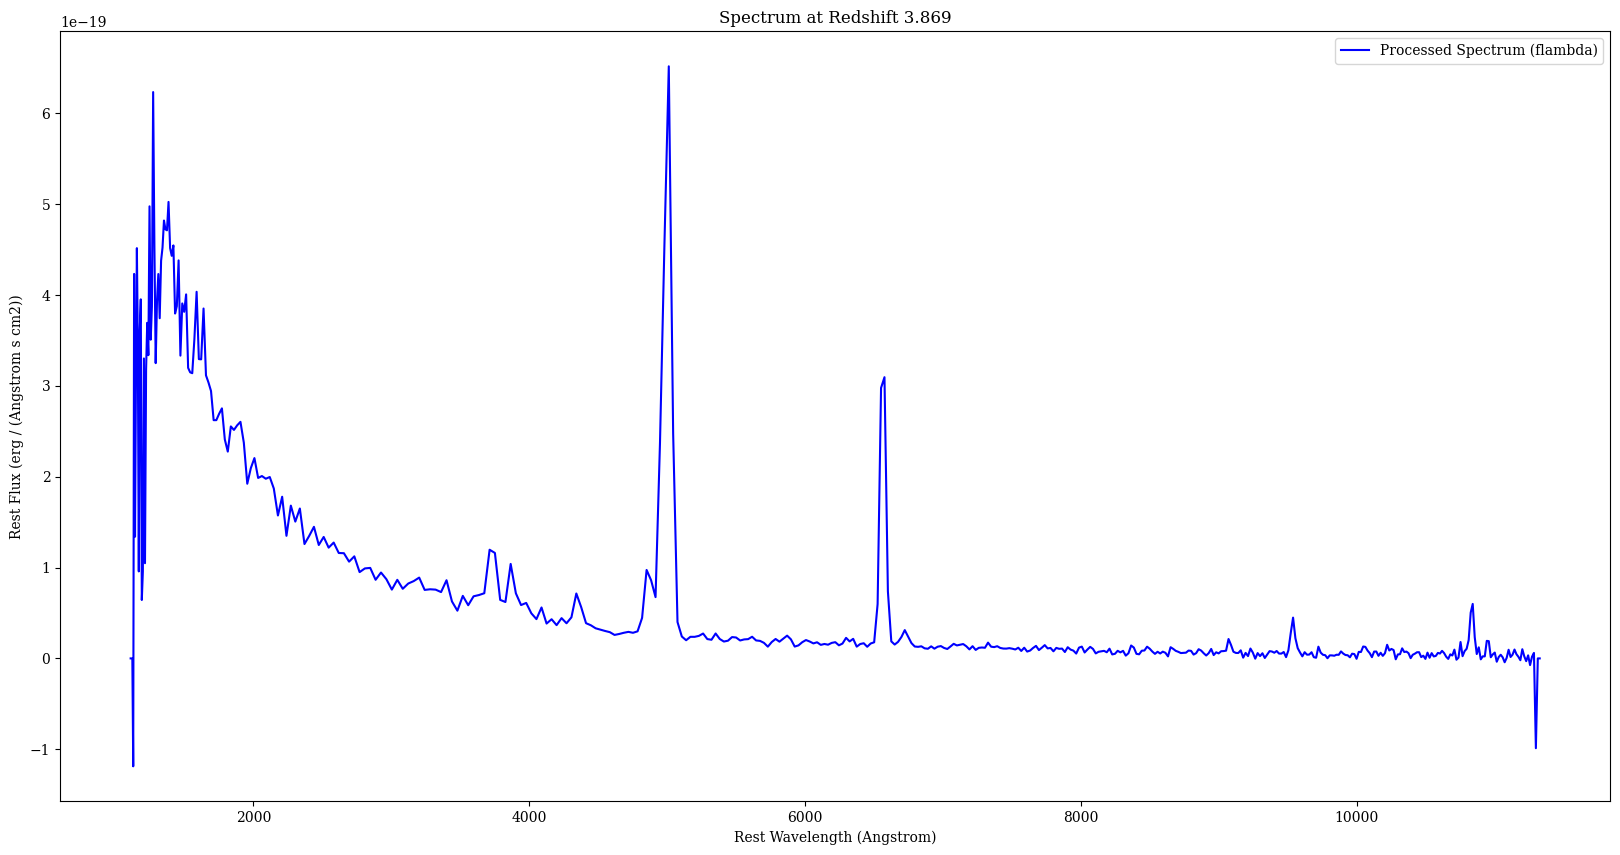

(<Figure size 2000x1000 with 1 Axes>,
 <Axes: title={'center': 'Spectrum at Redshift 3.869'}, xlabel='Rest Wavelength (Angstrom)', ylabel='Rest Flux (erg / (Angstrom s cm2))'>)

In [14]:
spec.show()

In [15]:
spec_grating

Spectrum_1d(z=3.871, λ_res=0.11 - 0.69 micron, 4667 points)

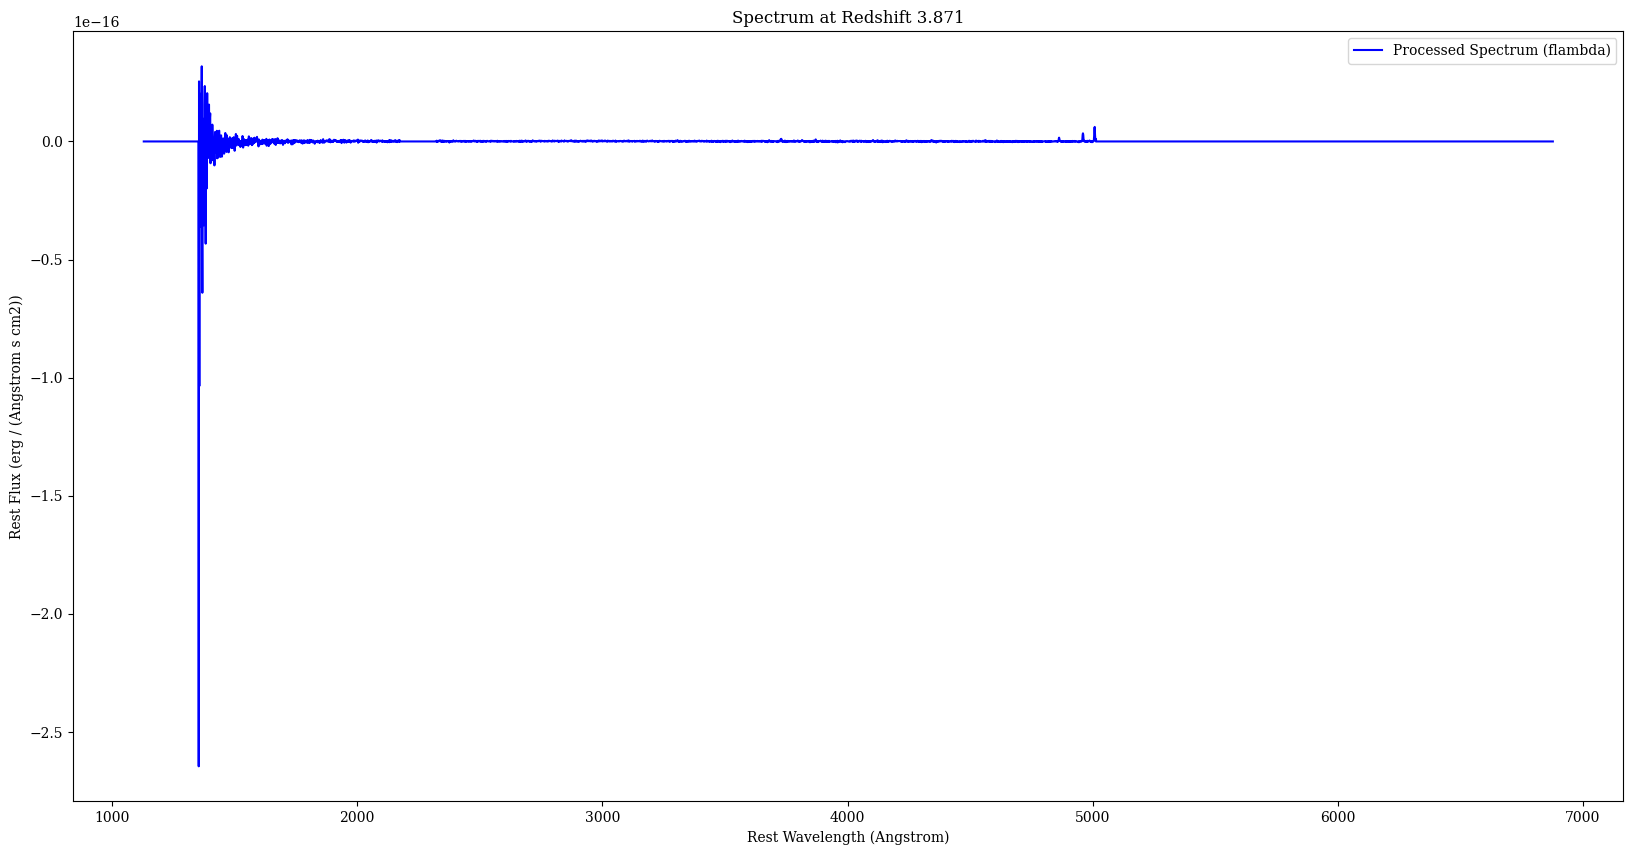

(<Figure size 2000x1000 with 1 Axes>,
 <Axes: title={'center': 'Spectrum at Redshift 3.871'}, xlabel='Rest Wavelength (Angstrom)', ylabel='Rest Flux (erg / (Angstrom s cm2))'>)

In [16]:
spec_grating.show()